<a href="https://colab.research.google.com/github/Markwema86/The-Capital-Budgeting-Tool-NPV-IRR-/blob/main/The_Capital_Budgeting_Tool_(NPV_%26_IRR).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Project 3: Capital Budgrting Tool
# Purpose: Calculate NPV and IRR for project evaluation

!pip install numpy-financial -q

import numpy as np
import numpy_financial as npf # the Excel equivalent library
import pandas as pd
import matplotlib.pyplot as plt

# Insatll numpy-financials if not already present
#!pip install numpy-financial -q

def calculate_npv(initial_investment, cash_flows, discount_rate):
  """
  Calculate the Net Present Value (NPV) of a project.

  Parameters:
  initial_investment (float): The initial investment required to execute the project.....Cash outflow at t=0(positive number, e.g., 1000000)
  cash_flows(list): List of future cash inflows(e.g., [300000, 400000, 500000])
  discount_rate(float): Required rate of return as decimal (e.g., 0.10 for 10%)

  Return:
  float: Net Present Value (NPV) of the project.
  """

  # Convert initial investment to negative outflow
  all_cash_flows = [-initial_investment] + list(cash_flows)

  # Calculate NPV mannually (for learning transparency)
  npv = 0
  for t, cf in enumerate(all_cash_flows):
    npv += cf / ((1 + discount_rate) ** t)

  return npv

def calculate_npv_numpy(initial_investment, cash_flows, discount_rate):
  """
  Alternative: Use numpy_financial (identical to Excel's NPV function).
  Note: Excel NPV assumes first cash flow is at t=1, so we handle t=0 separately.
  """
  return npf.npv(discount_rate, cash_flows) - initial_investment

# -- Test Case: A Manufacturing Plant ---
initial_cost = 1000000 # $1M upfront
future_cash = [300000, 400000, 500000, 300000] # Years 1-4
rate = 0.10 # 10% cost of capital

npv_manual = calculate_npv(initial_cost, future_cash, rate)
npv_excel = calculate_npv_numpy(initial_cost, future_cash, rate)

print(f"Manual NPV Calculation: ${npv_manual:,.2f}")
print(f"Excel(Numpy) NPV Calculation: ${npv_excel:,.2f}")
print(f"Decision: {'✅ ACCEPT' if npv_manual > 0 else '❌ REJECT'} the project")


Manual NPV Calculation: $183,867.22
Excel(Numpy) NPV Calculation: $302,253.94
Decision: ✅ ACCEPT the project


In [6]:
# Build the IRR Function
def calculate_irr(initial_investment, cash_flows, guess=0.10):
    """
    Calculate Internal Rate of Return using NumPy's IRR function.

    Parameters:
    initial_investment (float): Cash outflow at t=0 (positive number)
    cash_flows (list): List of future cash inflows
    guess (float): Initial guess for iterative solver (default 10%)

    Returns:
    float: IRR as decimal
    """
    all_cash_flows = [-initial_investment] + list(cash_flows)
    return npf.irr(all_cash_flows)

# Alternative: Manual implementation (for deeper understanding)
def calculate_irr_manual(initial_investment, cash_flows, tolerance=0.00001, max_iterations=1000):
    """
    Manual IRR using trial and error (Newton-Raphson approximation).
    This shows you what's happening under the hood.
    """
    all_cash = [-initial_investment] + list(cash_flows)

    # Binary search for IRR
    low = -0.99  # Can't be -100% or worse
    high = 0.99  # Cap at 99%

    for _ in range(max_iterations):
        mid = (low + high) / 2

        # Calculate NPV at mid rate
        npv = sum(cf / ((1 + mid) ** t) for t, cf in enumerate(all_cash))

        if abs(npv) < tolerance:
            return mid
        elif npv > 0:
            low = mid  # NPV positive → rate too low → increase
        else:
            high = mid  # NPV negative → rate too high → decrease

    return mid  # Return best approximation

# --- Test ---
irr = calculate_irr(initial_cost, future_cash)
irr_manual = calculate_irr_manual(initial_cost, future_cash)

print(f"\nIRR (NumPy): {irr * 100:.2f}%")
print(f"IRR (Manual Binary Search): {irr_manual * 100:.2f}%")
print(f"Decision: {'✅ ACCEPT' if irr > rate else '❌ REJECT'} (IRR > {rate*100}% hurdle)")


IRR (NumPy): 18.03%
IRR (Manual Binary Search): 18.03%
Decision: ✅ ACCEPT (IRR > 10.0% hurdle)


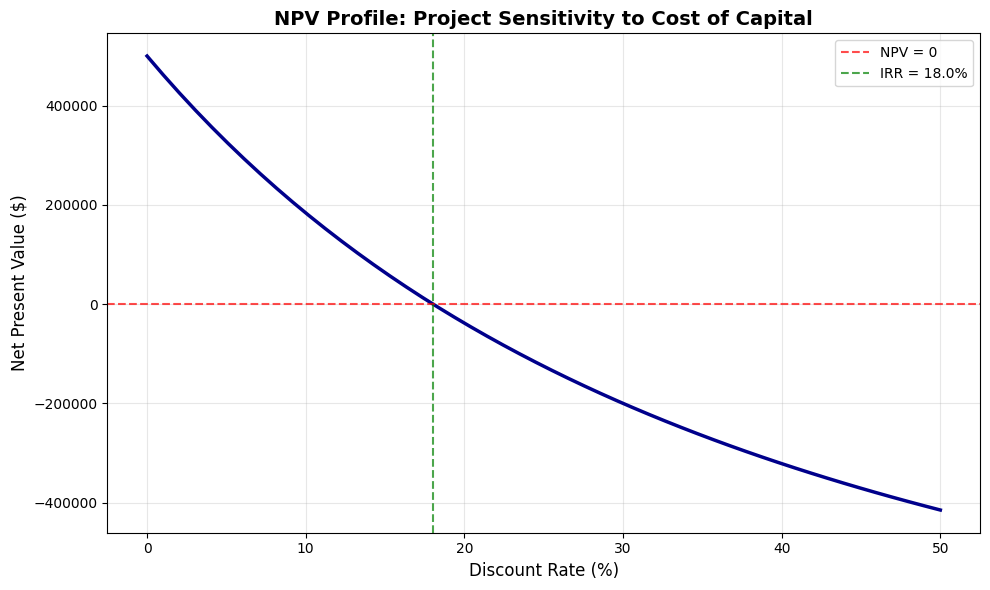

In [7]:
# The NPV Profile (Visualizing the Relationship)
def create_npv_profile(initial_investment, cash_flows, max_rate=0.50):
    """
    Generate and plot the NPV Profile.
    Shows where NPV crosses zero (the IRR).
    """
    rates = np.linspace(0, max_rate, 50)
    npvs = [calculate_npv(initial_investment, cash_flows, r) for r in rates]

    # Find IRR for vertical line
    irr_val = calculate_irr(initial_investment, cash_flows)

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(rates * 100, npvs, linewidth=2.5, color='darkblue')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, label='NPV = 0')
    plt.axvline(x=irr_val * 100, color='green', linestyle='--', alpha=0.7, label=f'IRR = {irr_val*100:.1f}%')

    plt.xlabel('Discount Rate (%)', fontsize=12)
    plt.ylabel('Net Present Value ($)', fontsize=12)
    plt.title('NPV Profile: Project Sensitivity to Cost of Capital', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return rates, npvs

# Generate the profile
rates, npvs = create_npv_profile(initial_cost, future_cash)

In [8]:
# The Mutually Exclusive Project Comparison - "Two projects, different scales, which one do you pick?"
def compare_projects(projects_dict, discount_rate):
    """
    Compare multiple mutually exclusive projects.

    Parameters:
    projects_dict (dict): {'Project A': {'cost': 1000, 'flows': [500, 600]}, ...}
    discount_rate (float): Required return

    Returns:
    DataFrame with comparison metrics
    """
    results = []

    for name, data in projects_dict.items():
        cost = data['cost']
        flows = data['flows']

        npv = calculate_npv(cost, flows, discount_rate)
        irr = calculate_irr(cost, flows)

        # Payback Period (non-discounted)
        cumulative = 0
        payback_years = 0
        for t, cf in enumerate(flows, 1):
            cumulative += cf
            if cumulative >= cost:
                payback_years = t + (cost - (cumulative - cf)) / cf
                break

        # Profitability Index (PI = NPV / Initial Investment)
        pi = npv / cost

        results.append({
            'Project': name,
            'NPV': npv,
            'IRR %': irr * 100,
            'Payback (Yrs)': payback_years,
            'Profitability Index': pi
        })

    df = pd.DataFrame(results)
    df = df.sort_values('NPV', ascending=False)
    return df.round(2)

# --- Test Case: Small High-Return vs Large Lower-Return ---
projects = {
    'Project A (Large)': {
        'cost': 1000000,
        'flows': [400000, 400000, 400000, 400000]
    },
    'Project B (Small)': {
        'cost': 100000,
        'flows': [60000, 60000, 60000]
    }
}

comparison = compare_projects(projects, discount_rate=0.10)
print("\n📊 Mutually Exclusive Project Comparison")
print("=" * 60)
print(comparison)
print("\n💡 Insight: Project A has higher NPV (creates more total wealth).")
print("💡 Insight: Project B has higher IRR and Profitability Index (more efficient per dollar).")
print("💡 CFA Answer: Choose Project A because NPV maximizes shareholder wealth.")


📊 Mutually Exclusive Project Comparison
             Project        NPV  IRR %  Payback (Yrs)  Profitability Index
0  Project A (Large)  267946.18  21.86           3.50                 0.27
1  Project B (Small)   49211.12  36.31           2.67                 0.49

💡 Insight: Project A has higher NPV (creates more total wealth).
💡 Insight: Project B has higher IRR and Profitability Index (more efficient per dollar).
💡 CFA Answer: Choose Project A because NPV maximizes shareholder wealth.


In [11]:
# The Real-World Challenge
# Scenario: A private equity firm is evaluating a leveraged buyout. They need to know if the deal works.
# LBO Cash Flow Scenario (Simplified)
lbo_cost = 50000000  # $50M purchase price
# Projected Free Cash Flows to Equity (after debt service)
lbo_cash_flows = [5000000, 8000000, 12000000, 15000000, 60000000]  # Year 5 includes exit
target_irr = 0.20  # PE firms typically target 20%+ IRR

lbo_npv = calculate_npv(lbo_cost, lbo_cash_flows, target_irr)
lbo_actual_irr = calculate_irr(lbo_cost, lbo_cash_flows)

print(f"\n🏦 Leveraged Buyout Analysis")
print("=" * 50)
print(f"Purchase Price: ${lbo_cost:,.0f}")
print(f"Target IRR: {target_irr*100:.0f}%")
print(f"NPV at Target IRR: ${lbo_npv:,.0f}")
print(f"Actual IRR: {lbo_actual_irr*100:.2f}%")
print(f"Decision: {'✅ EXECUTE LBO' if lbo_actual_irr > target_irr else '❌ PASS'}")


🏦 Leveraged Buyout Analysis
Purchase Price: $50,000,000
Target IRR: 20%
NPV at Target IRR: $-1,986,883
Actual IRR: 18.75%
Decision: ❌ PASS


**What I've Built**

**Component**	||**CFA Knowledge**	||**Python Skill**

NPV Function	->Time Value of Money	->Function definitions, loops

IRR Function	->Capital Budgeting Decision Rule	->numpy_financial, binary search logic

NPV Profile	->Sensitivity Analysis	->matplotlib visualization

Project Comparison	->Mutually Exclusive Project Rules	->pandas DataFrame creation

LBO Scenario	->Private Equity Valuation	->Real-world application